#### ***Neural Networks - Fraud Detection***

***Context***

*Nielsen reports that U.S. card fraud (credit, debt, etc) was reportedly 9 billion dollars in 2016 and expected to increase to 12 billion dollars by 2020. For perspective, in 2017 both PayPal's and Mastercard's revenue was only $10.8 billion each.*
*Therefore, it is important that credit card companies should be able to recognize fraudulent credit card transactions so that customers are not charged for items that they did not purchase.*

***Key Item covered***

*- Import Libraries*<br>
*- Data Load and Overview*<br>
*- Data Preprocessing - StandardScaler*<br>
*- Train/Test Split*<br>
*- Model Building and Scoring - RandomForestClassifier*<br>
*- Deep Neural Network - Model 1 - Basic NN with 5 fully connected layer with ReLu Activation and a dropout*<br>
*- Deep Neural Network - Model 2 - Early Stopping and Weight Initialization*<br>
*- Deep Neural Network - Model 3 - Changing Class Weight*<br>

#### ***Dataset Description***

*The dataset contains transactions made by credit cards in September 2013 by european cardholders. This dataset presents transactions that occurred in two days, where we have 492 frauds out of 284,807 transactions. The dataset is highly unbalanced, the positive class (frauds) account for 0.172% of all transactions.*

*This dataset only contains numerical input variables which are the result of a PCA transformation. Unfortunately, due to confidentiality issues, the original features and more background information about the data is not provided. Features V1, V2, ... V28 are the principal components obtained with PCA, the only features which have not been transformed with PCA are 'Time' and 'Amount'.* 

- *`Time` contains the seconds elapsed between each transaction and the first transaction in the dataset.* 
- *`Amount` is the transaction Amount, this feature can be used for example-dependant cost-senstive learning.*
- *`Class` is the response variable and it takes value 1 in case of fraud and 0 otherwise.*

#### ***Import necessary Libraries*** 

In [1]:
#importing tensorflow
import tensorflow as tf
print(tf.__version__)

2.20.0


In [2]:
# Data Handling and Preprocessing
import pandas as pd
import numpy as np
import random
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.utils import class_weight

# Model Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_curve,
    auc
)

# Deep Learning Libraries
import tensorflow as tf
import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras import optimizers
from tensorflow.keras import backend

from keras import backend as K

# visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


#### ***Import data***

In [3]:
#reading dataset
data = pd.read_csv('data/45_creditcard.csv')

#### ***Dataset Overview***

In [4]:
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
data.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


***Check the missing values*** 

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

- *284807 rows and 31 attributes including target class. No missing values*

In [7]:
#Number of distinct categories or classes i.e., Fraudulent and Genuine
data['Class'].nunique()

2

- *Two Output Class*

In [8]:
data.Class.value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

*Highly Imbalance Data - only 0.17% fradulent*

In [9]:
print("****** Losses due to fraud:")
print("### Total amount lost to fraud")
print(f"${data.Amount[data.Class == 1].sum():,.2f}")
print("### Mean amount per fraudulent transaction")
print(f"${data.Amount[data.Class == 1].mean():,.2f}")
print()

print("****** Compare to normal transactions:")
print("### Total amount from normal transactions")
print(f"${data.Amount[data.Class == 0].sum():,.2f}")
print("### Mean amount per normal transaction")
print(f"${data.Amount[data.Class == 0].mean():,.2f}")

****** Losses due to fraud:
### Total amount lost to fraud
$60,127.97
### Mean amount per fraudulent transaction
$122.21

****** Compare to normal transactions:
### Total amount from normal transactions
$25,102,462.04
### Mean amount per normal transaction
$88.29


***The below plot after PCA gives a better visualization of the imbalance in the datasets. PCA helps to visualize the high dimensional data into lower dimensions*** 

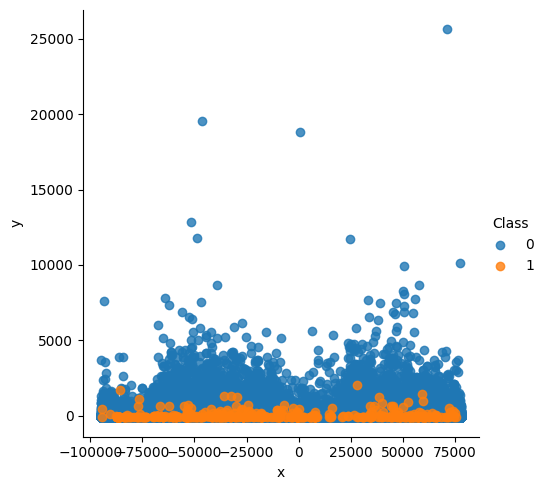

In [10]:
#PCA is performed for visualization only

pca = PCA(n_components=2)
creditcard_2d= pd.DataFrame(pca.fit_transform(data.iloc[:,0:30])) # applied PCA on all columns except the target class
creditcard_2d= pd.concat([creditcard_2d, data['Class']], axis=1) # concatenating the target class column to PCA output
creditcard_2d.columns= ['x', 'y', 'Class'] # renaming the columns
sns.lmplot(x='x', y='y', data=creditcard_2d, fit_reg=False, hue='Class'); # plotting the PCA output with target class as hue

***PCA gives a better visualization of the imbalance in the datasets.***

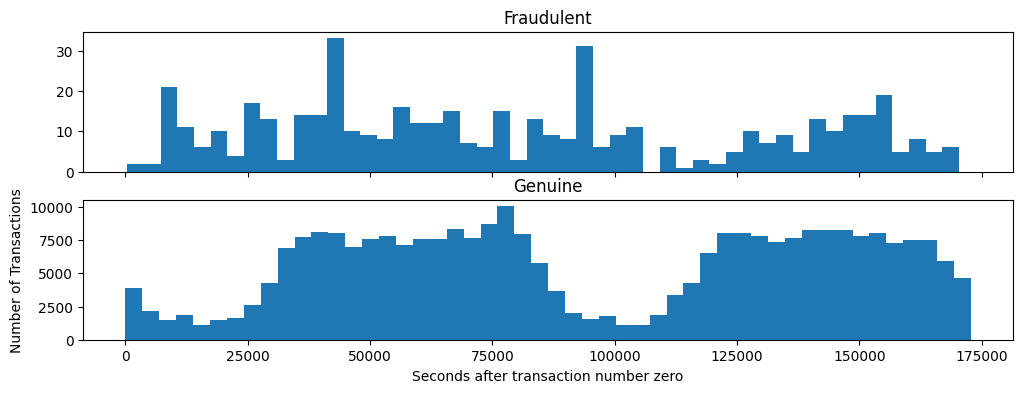

In [11]:
#Histrogram for feature Time
f, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(12,4))

ax1.hist(data["Time"][data["Class"] == 1], bins = 50)
ax1.set_title('Fraudulent')

ax2.hist(data["Time"][data["Class"] == 0], bins = 50)
ax2.set_title('Genuine')

plt.xlabel('Seconds after transaction number zero')
plt.ylabel('Number of Transactions')
plt.show()

* The transactions occur in a cyclic way. But the time feature does not provide any useful information as the time when the first transaction was initiated is not given. Thus, we'll drop this feature.

In [12]:
#Dropping time feature
data = data.drop("Time", axis = 1)

***Let's take a look at the V1,...,V28 features.***

In [13]:
Vfeatures = data.iloc[:,1:29].columns
print(Vfeatures)

Index(['V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12',
       'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22',
       'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount'],
      dtype='object')


#### ***Separating response variable and predictors*** 

In [14]:
X_data = data.iloc[:,0:29]
y_data = data.iloc[:, -1]

In [15]:
#printing the shape of the data 
print(X_data.shape)
print(y_data.shape)

(284807, 29)
(284807,)


#### ***Data Pre-processing***

In [16]:
#Standardizing the Amount column (All other 'V' columns are already scaled as they've undergone PCA transformation).
from sklearn.preprocessing import StandardScaler
X_data['normalizedAmount'] = StandardScaler().fit_transform(X_data['Amount'].values.reshape(-1,1))  # Normalize 'Amount' in [-1,+1] range
X_data= X_data.drop(['Amount'],axis=1)

#### ***Splitting the Data into train and test set***

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size = 0.2, random_state = 7)

In [18]:

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(227845, 29)
(56962, 29)
(227845,)
(56962,)


#### ***Model Building***

***Model evaluation criterion***

***Model can make wrong predictions as:***
* *Predicting a transaction is fraud  and the transaction  is not fraud - True Positive*
* *Predicting a transaction  is not fraud and  transaction is  fraud - True Negative*

***Which case is more important?*** 
* *Predicting that transaction is not fraud but it is Fraud. It might enable lot of criminal activities and heavy loss to the bank* 

***How to reduce this loss i.e need to reduce False Negative?***
* *Company would want `Recall` to be maximized, greater the Recall higher the chances of minimizing false Negative. Hence, the focus should be on increasing Recall or minimizing the false Negative or in other words identifying the True Positive(i.e. Class 1) so that the Company can identify the fraud transaction.*

#### ***Random Forest***

In [19]:
from sklearn.ensemble import RandomForestClassifier

# Set random_state for reproducibility
random_forest = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
random_forest.fit(X_train, y_train.values.ravel())

# Predict and evaluate
y_pred = random_forest.predict(X_test)
score = random_forest.score(X_test, y_test)
print(f"Model accuracy: {score:.4f}")

Model accuracy: 0.9996


In [20]:

def make_confusion_matrix(cf,
                          group_names=None,
                          categories='auto',
                          count=True,
                          percent=True,
                          cbar=True,
                          xyticks=True,
                          xyplotlabels=True,
                          sum_stats=True,
                          figsize=None,
                          cmap='Blues',
                          title=None):
    '''
    This function will make a pretty plot of an sklearn Confusion Matrix cm using a Seaborn heatmap visualization.
    Arguments
    '''


    # CODE TO GENERATE TEXT INSIDE EACH SQUARE
    blanks = ['' for i in range(cf.size)]

    if group_names and len(group_names)==cf.size:
        group_labels = ["{}\n".format(value) for value in group_names]
    else:
        group_labels = blanks

    if count:
        group_counts = ["{0:0.0f}\n".format(value) for value in cf.flatten()]
    else:
        group_counts = blanks

    if percent:
        group_percentages = ["{0:.2%}".format(value) for value in cf.flatten()/np.sum(cf)]
    else:
        group_percentages = blanks

    box_labels = [f"{v1}{v2}{v3}".strip() for v1, v2, v3 in zip(group_labels,group_counts,group_percentages)]
    box_labels = np.asarray(box_labels).reshape(cf.shape[0],cf.shape[1])


    # CODE TO GENERATE SUMMARY STATISTICS & TEXT FOR SUMMARY STATS
    if sum_stats:
        #Accuracy is sum of diagonal divided by total observations
        accuracy  = np.trace(cf) / float(np.sum(cf))

        #if it is a binary confusion matrix, show some more stats
        if len(cf)==2:
            #Metrics for Binary Confusion Matrices
            precision = cf[1,1] / sum(cf[:,1])
            recall    = cf[1,1] / sum(cf[1,:])
            f1_score  = 2*precision*recall / (precision + recall)
            stats_text = "\n\nAccuracy={:0.3f}\nPrecision={:0.3f}\nRecall={:0.3f}\nF1 Score={:0.3f}".format(
                accuracy,precision,recall,f1_score)
        else:
            stats_text = "\n\nAccuracy={:0.3f}".format(accuracy)
    else:
        stats_text = ""


    # SET FIGURE PARAMETERS ACCORDING TO OTHER ARGUMENTS
    if figsize==None:
        #Get default figure size if not set
        figsize = plt.rcParams.get('figure.figsize')

    if xyticks==False:
        #Do not show categories if xyticks is False
        categories=False


    # MAKE THE HEATMAP VISUALIZATION
    plt.figure(figsize=figsize)
    sns.heatmap(cf,annot=box_labels,fmt="",cmap=cmap,cbar=cbar,xticklabels=categories,yticklabels=categories)

    if xyplotlabels:
        plt.ylabel('True label')
        plt.xlabel('Predicted label' + stats_text)
    else:
        plt.xlabel(stats_text)
    
    if title:
        plt.title(title)

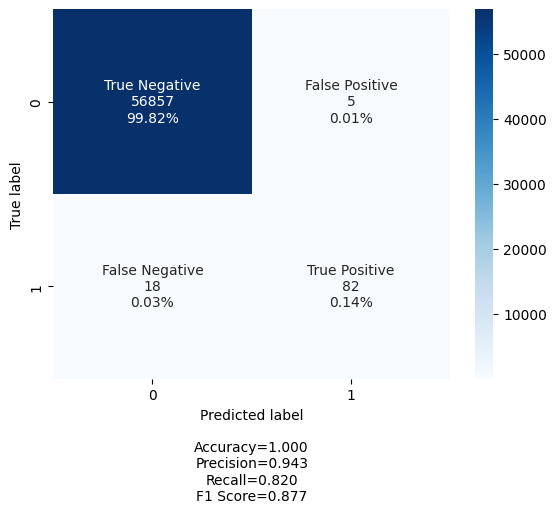

In [21]:
cm3=confusion_matrix(y_test, y_pred)
labels = ['True Negative','False Positive','False Negative','True Positive']
make_confusion_matrix(cm3, 
                      group_names=labels,
                      #categories=categories, 
                      cmap='Blues')

***RandomForest Model Conclusion:***

- *On Test Data, while only 5 regular transactions are wrongly predicted as fraudulent, the model only detects 82% of the fraudulent transactions. As a consequence 18 fraudulent transactions are not detected (False Negatives).*

- *Let's see if we can improve this performance with other machine learning / deep learning models*

#### ***Deep Neural Network***

***`Model-1`***

- *We will use a simple Neural Network (NN) made of 5 fully-connected layers with ReLu activation. The NN takes a vector of length 29 as input. This represents the information related to each transactions, ie each line with 29 columns from the dataset. For each transaction, the final layer will output a probability distribution (sigmoid activation function) and classify either as not fraudulent (0) or fraudulent (1).*
- *A dropout step is included to prevent overfitting.*

In [22]:
# Set seeds for reproducibility
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

#initialize the model
model = Sequential()

# This adds the input layer (by specifying input dimension) AND the first hidden layer (units)
# Input layer + first hidden layer
model.add(Input(shape=(29,)))           # Input layer
model.add(Dense(16, activation='relu')) # First hidden layer

# Hidden layers
model.add(Dense(24, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(24, activation='relu'))
model.add(Dense(24, activation='relu'))

# Output layer for binary classification
model.add(Dense(1, activation='sigmoid'))

# Create optimizer with default learning rate
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

***Model Summary***

In [23]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │           408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 24)             │           600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 24)             │           600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            25 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,113 (8.25 KB)

 Trainable params: 2,113 (8.25 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
#fitting the model
history=model.fit(X_train,y_train,batch_size=15,epochs=10,validation_split=0.2)

Epoch 1/10
12152/12152 ━━━━━━━━━━━━━━━━━━━━ 6s 423us/step - accuracy: 0.9983 - loss: 0.0101 - val_accuracy: 0.9995 - val_loss: 0.0026
Epoch 2/10
12152/12152 ━━━━━━━━━━━━━━━━━━━━ 5s 411us/step - accuracy: 0.9993 - loss: 0.0044 - val_accuracy: 0.9995 - val_loss: 0.0025
Epoch 3/10
12152/12152 ━━━━━━━━━━━━━━━━━━━━ 5s 406us/step - accuracy: 0.9993 - loss: 0.0041 - val_accuracy: 0.9995 - val_loss: 0.0027
Epoch 4/10
12152/12152 ━━━━━━━━━━━━━━━━━━━━ 5s 402us/step - accuracy: 0.9993 - loss: 0.0040 - val_accuracy: 0.9995 - val_loss: 0.0023
Epoch 5/10
12152/12152 ━━━━━━━━━━━━━━━━━━━━ 5s 404us/step - accuracy: 0.9993 - loss: 0.0037 - val_accuracy: 0.9995 - val_loss: 0.0028
Epoch 6/10
12152/12152 ━━━━━━━━━━━━━━━━━━━━ 5s 405us/step - accuracy: 0.9993 - loss: 0.0036 - val_accuracy: 0.9995 - val_loss: 0.0025
Epoch 7/10
12152/12152 ━━━━━━━━━━━━━━━━━━━━ 5s 404us/step - accuracy: 0.9993 - loss: 0.0035 - val_accuracy: 0.9994 - val_loss: 0.0028
Epoch 8/10
12152/12152 ━━━━━━━━━━━━━━━━━━━━ 5s 403us/step - ac

***Plotting the train and test loss***

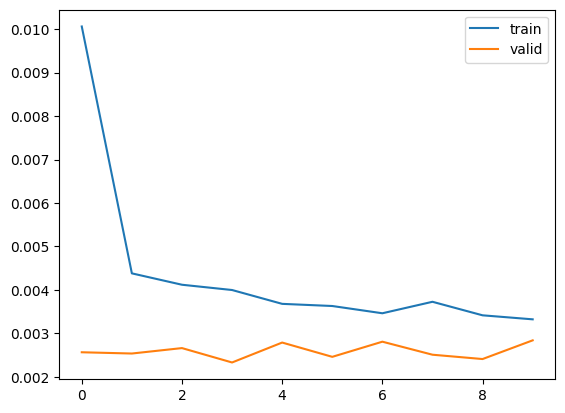

In [25]:
# Capturing learning history per epoch
hist  = pd.DataFrame(history.history)
hist['epoch'] = history.epoch

# Plotting accuracy at different epochs
plt.plot(hist['loss'])
plt.plot(hist['val_loss'])
plt.legend(("train" , "valid") , loc =0)

***Evaluation***
*Keras model can be evaluated with `evaluate()` function*

In [26]:
score = model.evaluate(X_test, y_test)
print(f"Test Loss: {score[0]:.4f}")
print(f"Test Accuracy: {score[1]:.4f}")

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 0s 266us/step - accuracy: 0.9994 - loss: 0.0039
Test Loss: 0.0039
Test Accuracy: 0.9994


***Confusion Matrix*** 

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 0s 192us/step


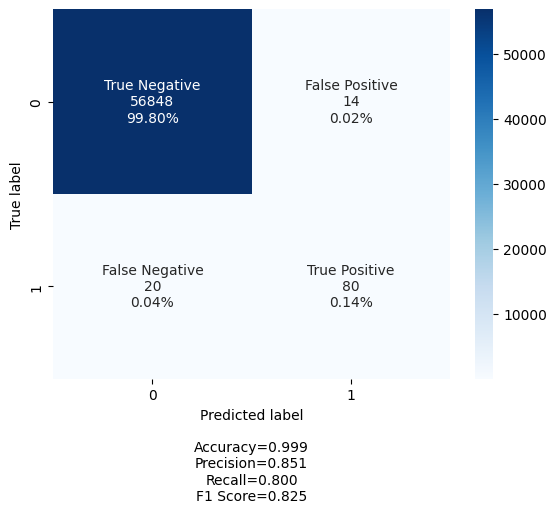

In [27]:
## Confusion Matrix on unsee test set
import seaborn as sn
y_pred1 = model.predict(X_test)
for i in range(len(y_test)):
    if y_pred1[i]>0.5:
        y_pred1[i]=1 
    else:
        y_pred1[i]=0


cm2=confusion_matrix(y_test, y_pred1)
labels = ['True Negative','False Positive','False Negative','True Positive']
#categories = [ 'Not_Fraud','Fraud']
make_confusion_matrix(cm2, 
                      group_names=labels,
                      #categories=categories, 
                      cmap='Blues')

***Deep Neural Network Model 1 - Conclusion:***

- *Detection of fraudulent transtions did not improve compared to the previous Randomforest Model*

- *There are 100 fraudelent transactions in the test data, and 20 of them were not identified correctly by the model*

***`Model-2`***

***`Early stopping`:*** 

*During training, the model is evaluated on a holdout validation dataset after each epoch. If the performance of the model on the validation dataset starts to degrade or no improvement (e.g. loss begins to increase or accuracy begins to decrease), then the training process is stopped after the certian interations.The model at the time that training is stopped is then used and is known to have good generalization performance.*

***This procedure is called `early stopping` and is perhaps one of the oldest and most widely used forms of neural network regularization.***

***`Weight Initialization`***

*Weight initialization is an important consideration in the design of a neural network model.*

*The nodes in neural networks are composed of parameters referred to as weights used to calculate a weighted sum of the inputs.*

*Neural network models are fit using an optimization algorithm called `Stochastic Gradient Descent` that incrementally changes the network weights to minimize a loss function, hopefully resulting in a set of weights for the mode that is capable of making useful predictions.*

*This optimization algorithm requires a starting point in the space of possible weight values from which to begin the optimization process. Weight initialization is a procedure to set the weights of a neural network to small random values that define the starting point for the optimization (learning or training) of the neural network model.*

***There are many WI techniques as follows:***

- *Random normal initialization*
- *Random Uniform initialization*
- *Xaviour Initialization*
- *He Initialization*

In [28]:
# clearing the session
backend.clear_session()

In [29]:
# Set seeds for reproducibility
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

#Training Multi-layer perceptron with 2 hidden layers
#adding earlystopping callback
es= keras.callbacks.EarlyStopping(monitor='val_loss',
                              min_delta=0,
                              patience=15,
                              verbose=0, mode='min', restore_best_weights= True)

n_inputs = X_train.shape[1]
Model2 = Sequential()

#Initializing the weights uisng hue_normal 
Model2.add(Dense(65, input_shape=(n_inputs, ), kernel_initializer='he_normal', activation='relu'))
Model2.add(Dropout(0.5))
Model2.add(Dense(65, kernel_initializer='he_normal', activation='relu'))
Model2.add(Dropout(0.5))
Model2.add(Dense(1, kernel_initializer='he_normal', activation='sigmoid'))

Model2.compile(optimizers.Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
    
his_mod2= Model2.fit(X_train, y_train, validation_split=0.2, batch_size=700, epochs=40, callbacks=[es], shuffle=True, verbose=1)

Epoch 1/40


/Users/nirmalkumar/Documents/Developer/AIML Repository/venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


261/261 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9750 - loss: 0.0969 - val_accuracy: 0.9986 - val_loss: 0.0092
Epoch 2/40
261/261 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9984 - loss: 0.0162 - val_accuracy: 0.9994 - val_loss: 0.0038
Epoch 3/40
261/261 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9987 - loss: 0.0100 - val_accuracy: 0.9994 - val_loss: 0.0036
Epoch 4/40
261/261 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9988 - loss: 0.0085 - val_accuracy: 0.9995 - val_loss: 0.0032
Epoch 5/40
261/261 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9990 - loss: 0.0069 - val_accuracy: 0.9995 - val_loss: 0.0031
Epoch 6/40
261/261 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9990 - loss: 0.0065 - val_accuracy: 0.9995 - val_loss: 0.0028
Epoch 7/40
261/261 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9990 - loss: 0.0063 - val_accuracy: 0.9994 - val_loss: 0.0027
Epoch 8/40
261/261 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9991 - loss: 0.0053 - val_accuracy: 0.9994 - val_

Plotting the train and validation loss

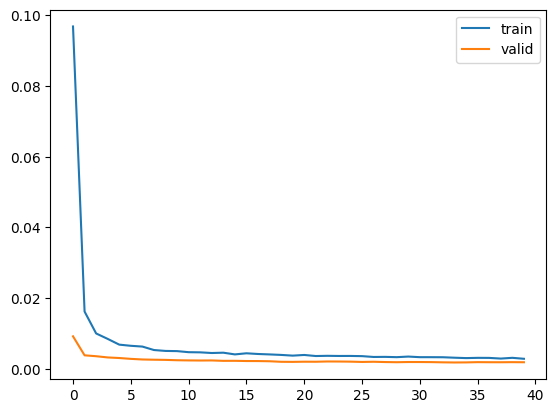

In [30]:
# Capturing learning history per epoch
hist  = pd.DataFrame(his_mod2.history)
hist['epoch'] = his_mod2.epoch

# Plotting accuracy at different epochs
plt.plot(hist['loss'])
plt.plot(hist['val_loss'])
plt.legend(("train" , "valid") , loc =0)

Plotting confusion matrix 

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 0s 190us/step


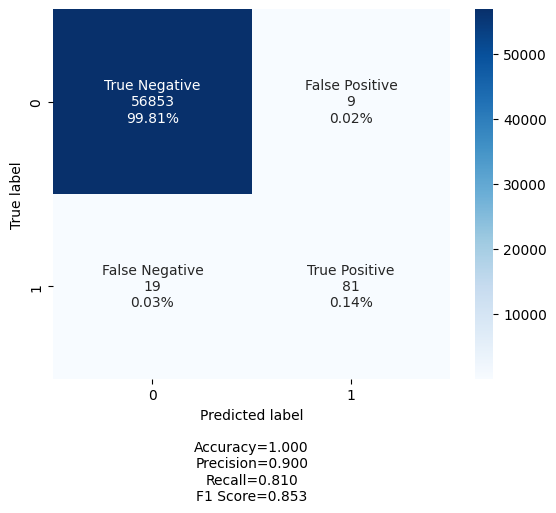

In [31]:
## Confusion Matrix on unsee test set
import seaborn as sn
y_pred1 = Model2.predict(X_test)
for i in range(len(y_test)):
    if y_pred1[i]>0.5:
        y_pred1[i]=1 
    else:
        y_pred1[i]=0



cm2=confusion_matrix(y_test, y_pred1)
labels = ['True Negative','False Positive','False Negative','True Positive']
categories = [ 'Not_Fraud','Fraud']
make_confusion_matrix(cm2, 
                      group_names=labels,
                      #categories=categories, 
                      cmap='Blues')

***Deep Neural Network Model 2 - Conclusion:***

- *Not much improvement*

***`Model 3` - Changing Class Weight***

***Weighted loss to account for large class imbalance in train dataset***
- *We will adjust the class imbalance by giving additional weight to the loss associated to errors made on fraudulent transaction detection.*


In [32]:
# Compute class weights using keyword arguments
class_weights_array = class_weight.compute_class_weight(
    class_weight='balanced', # automatically adjust weights inversely proportional to class frequencies
    classes=np.unique(y_train), # lists all the unique classes found in the target variable
    y=y_train.values.ravel()  # ensure it's a 1D array
)

# Convert to dictionary format for use in model training
class_weights = dict(zip(np.unique(y_train), class_weights_array)) # converts the array of weights to a dictionary format

In [33]:
model.fit(X_train,y_train,batch_size=15,epochs=5, class_weight=class_weights, shuffle=True)

Epoch 1/5
15190/15190 ━━━━━━━━━━━━━━━━━━━━ 6s 357us/step - accuracy: 0.9756 - loss: 0.3286
Epoch 2/5
15190/15190 ━━━━━━━━━━━━━━━━━━━━ 5s 355us/step - accuracy: 0.9779 - loss: 0.2350
Epoch 3/5
15190/15190 ━━━━━━━━━━━━━━━━━━━━ 5s 350us/step - accuracy: 0.9753 - loss: 0.2905
Epoch 4/5
15190/15190 ━━━━━━━━━━━━━━━━━━━━ 5s 347us/step - accuracy: 0.9655 - loss: 0.3162
Epoch 5/5
15190/15190 ━━━━━━━━━━━━━━━━━━━━ 5s 350us/step - accuracy: 0.9595 - loss: 0.5782


In [34]:
score_weighted = model.evaluate(X_test, y_test)
print(f"Test Loss: {score_weighted[0]:.4f}")
print(f"Test Accuracy: {score_weighted[1]:.4f}")

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 0s 265us/step - accuracy: 0.9927 - loss: 0.0230
Test Loss: 0.0230
Test Accuracy: 0.9927


1781/1781 ━━━━━━━━━━━━━━━━━━━━ 0s 192us/step


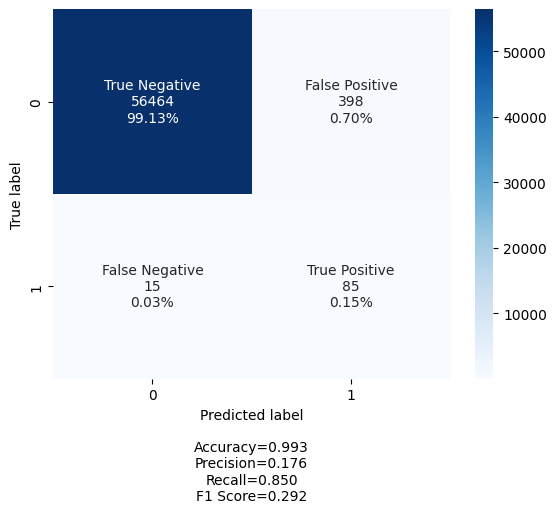

In [35]:
## Confusion Matrix on unsee test set
import seaborn as sn
y_pred1 = model.predict(X_test)
for i in range(len(y_test)):
    if y_pred1[i]>0.5:
        y_pred1[i]=1 
    else:
        y_pred1[i]=0



cm2=confusion_matrix(y_test, y_pred1)
labels = ['True Negative','False Positive','False Negative','True Positive']
categories = [ 'Not_Fraud','Fraud']
make_confusion_matrix(cm2, 
                      group_names=labels,
                      #categories=categories, 
                      cmap='Blues')

***Deep Neural Network Model 3 - Conclusion:***

- *False Negative has imroved but at the cost of False Positive*